In [341]:
!pip install seaborn numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [342]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker

import pandas as pd
import seaborn as sns

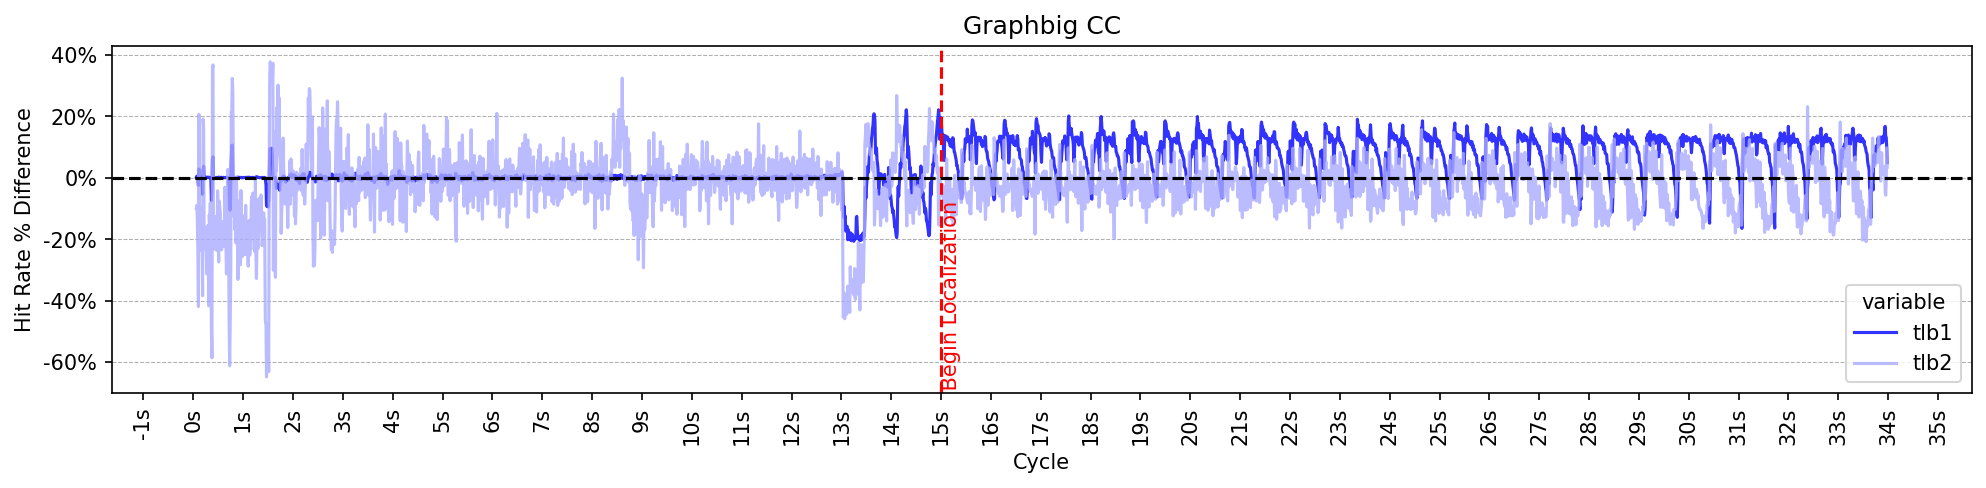

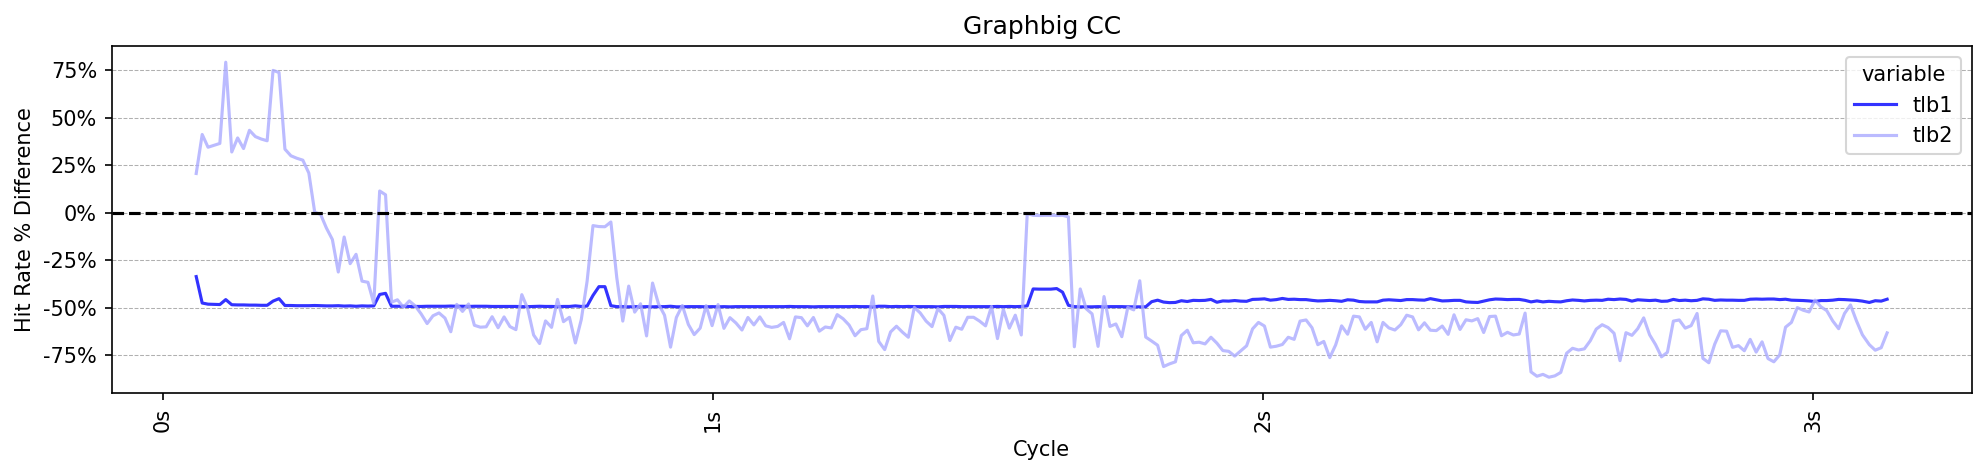

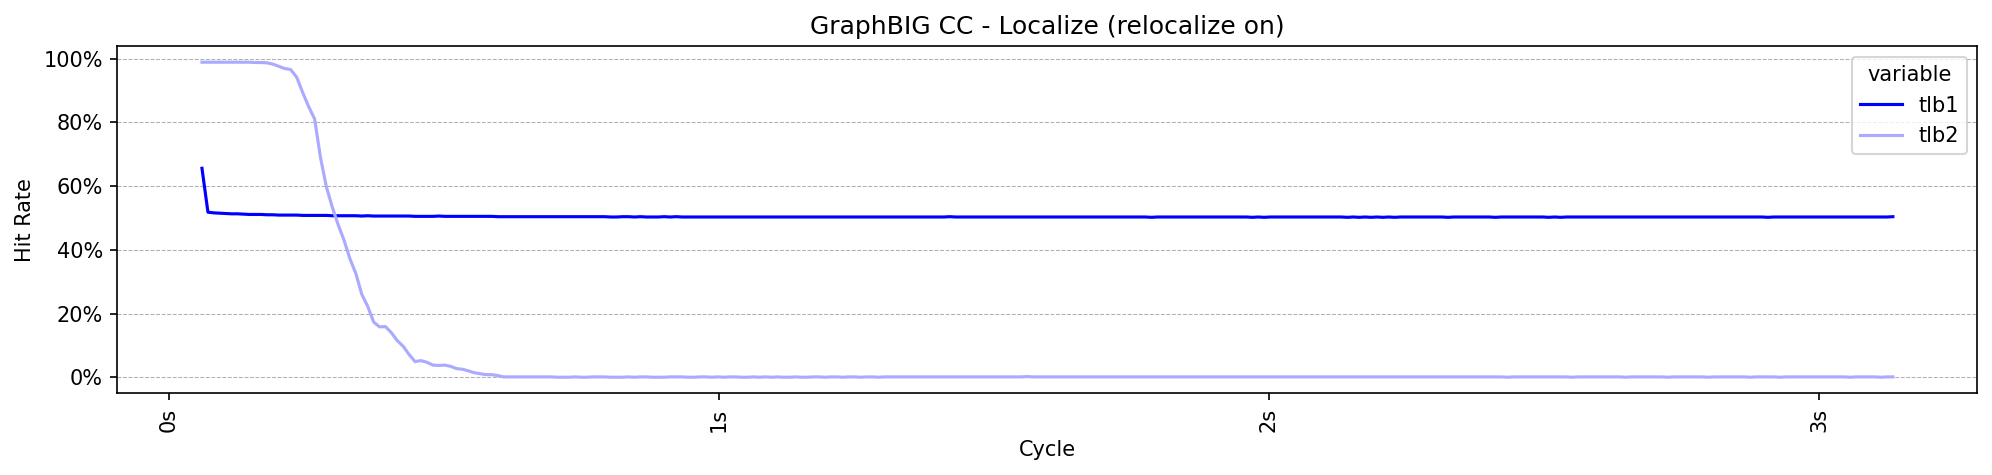

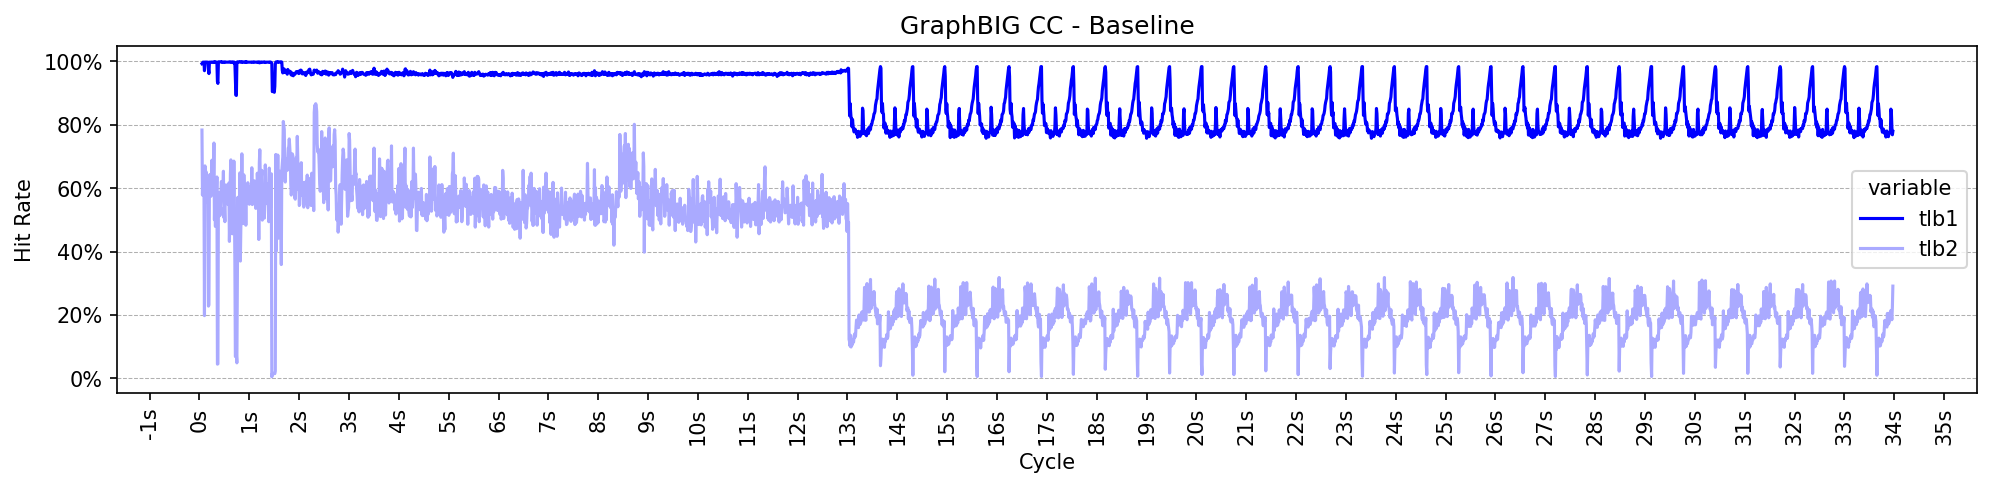

In [343]:
def plot_hitrate(path, title, locstart=None):
  df = pd.read_csv(path, header=0)
  # remove the column 'dcache1'
  df = df.drop(columns=['dcache1', 'dcache2', 'htlb1', 'htlb2'])

  df = df.melt(id_vars=['cycle'], var_name='variable', value_name='value')


  fig = plt.figure(figsize=(16, 3), dpi=150)
  sns.lineplot(df, x='cycle', y='value', hue='variable', palette={
    'tlb1': '#00F',
    'tlb2': '#aaF',

    'htlb1': '#F00',
    'htlb2': '#Faa',
    'dcache1': 'black',
    'dcache2': 'grey',
  })

  if locstart is not None:
    # draw a vertical line at locstart
    plt.axvline(x=locstart * 1e9, color='red', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = plt.ylim()
    plt.text(locstart * 1e9, y_min, ' Begin Localization', rotation=90, color='red', fontsize=10)


  # set x axis ticks to every 1e9 cycles
  plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1e9))
  plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  # format y axis as percentage
  plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
  # y axis grid
  plt.gca().yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)
  plt.title(title)
  plt.xlabel('Cycle')
  plt.ylabel('Hit Rate')
  plt.xticks(rotation=90)


def plot_hitrate_diff(baseline, localizing, title, locstart):
  to_drop = ['dcache1', 'dcache2', 'htlb1', 'htlb2']
  dfb = pd.read_csv(baseline, header=0).drop(columns=to_drop)
  dfl = pd.read_csv(localizing, header=0).drop(columns=to_drop)

  dfl['tlb1'] = dfl['tlb1'] - dfb['tlb1']
  dfl['tlb2'] = dfl['tlb2'] - dfb['tlb2']

  df = dfl.melt(id_vars=['cycle'], var_name='variable', value_name='value')


  fig = plt.figure(figsize=(16, 3), dpi=150)
  sns.lineplot(df, x='cycle', y='value', hue='variable', alpha=0.8, palette={
    'tlb1': '#00F',
    'tlb2': '#aaF',

    'htlb1': '#F00',
    'htlb2': '#Faa',
    'dcache1': 'black',
    'dcache2': 'grey',
  })

  if locstart is not None:
    # draw a vertical line at locstart
    plt.axvline(x=locstart * 1e9, color='red', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = plt.ylim()
    plt.text(locstart * 1e9, y_min, ' Begin Localization', rotation=90, color='red', fontsize=10)

  plt.axhline(y=0, color='black', linestyle='--')
    # get the current lower bound of y axis

  # set x axis ticks to every 1e9 cycles
  plt.gca().xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1e9))
  plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  # format y axis as percentage
  plt.gca().yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x:.0f}%"))
  # y axis grid
  plt.gca().yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)
  plt.title(title)
  plt.xlabel('Cycle')
  plt.ylabel('Hit Rate % Difference')
  plt.xticks(rotation=90)
  pass


# plot_hitrate_diff("../hitrate_python_baseline.csv", "../hitrate_python_localize.csv", "Python Nbody", locstart=0.5)
plot_hitrate_diff("../hitrate_cc_baseline.csv", "../hitrate_cc_localize.csv", "Graphbig CC", locstart=15)

plot_hitrate_diff("../hitrate_cc_baseline.csv", "../hitrate.csv", "Graphbig CC", locstart=None)
plot_hitrate('../hitrate.csv', "GraphBIG CC - Localize (relocalize on)")
plot_hitrate('../hitrate_cc_baseline.csv', "GraphBIG CC - Baseline")
# plot_hitrate('../hitrate_cc_localize.csv', "GraphBIG CC Hitrate per 10ms window - Localizing", locstart=15)

/tmp/ipykernel_1047517/3792490004.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_locality['id'] = df_locality['id'].str.split('-').str[1].astype(int)
/tmp/ipykernel_1047517/3792490004.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non_locality['id'] = df_non_locality['id'].str.split('-').str[1].astype(int)


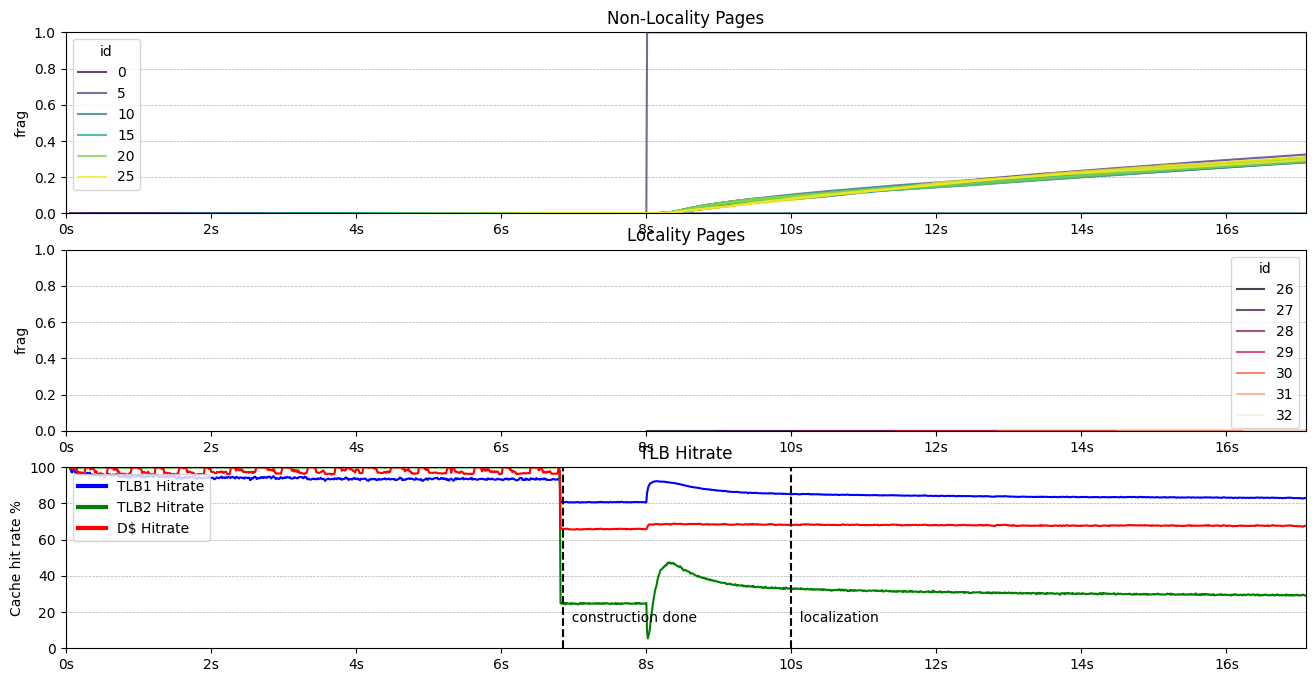

In [611]:
def plot_frag(frag_file, hitrate_file, marks = {}):
  df = pd.read_csv(frag_file)

  # break the dataframe into two dataframes. One where the `id` contains `Locality` and one where it does not
  df_locality = df[df['id'].str.contains('Locality')]
  df_non_locality = df[~df['id'].str.contains('Locality')]
  # reformat the id column to be the integer after the - char
  df_locality['id'] = df_locality['id'].str.split('-').str[1].astype(int)
  df_non_locality['id'] = df_non_locality['id'].str.split('-').str[1].astype(int)

  palette = {}
  # for each unique value in df['id']
  for i, id in enumerate(df['id'].unique()):
    if 'Locality' in id:
      palette[id] = '#000'
    else:
      palette[id] = '#88f'

  # make two figures on top of eachother

  fig, axs = plt.subplots(3, 1, figsize=(16, 8), dpi=100)

  bits = [
    (axs[0], 'Non-Locality Pages', df_non_locality, 'viridis'), 
    (axs[1], 'Locality Pages', df_locality, 'rocket')
  ]



  for ax, title, df, palette in bits:
    if len(df) == 0:
      continue
    g = sns.lineplot(df, x='cycle', y='frag', hue='id', alpha=0.75, palette=palette, ax=ax)
    # set the title
    ax.set_title(title)
    # set the y axis to be between 0 and 1
    ax.set_ylim(0, 1)
    g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
    ax.set_xlabel(None)
    g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)

  df = pd.read_csv(hitrate_file)
  bits = [
    ('tlb1', 'TLB1 Hitrate', 'blue'),
    ('tlb2', 'TLB2 Hitrate', 'green'),
    ('dcache1', 'D$ Hitrate', 'red'),
  ]
  for col, title, color in bits:
    g = sns.lineplot(df, x='cycle', y=col, color=color, alpha=1.0, ax=axs[2])
    g.set_title(title)
    # sns.regplot(df, x='cycle', y=col, color=color, ax=axs[2], alpha=0.5, scatter=False, line_kws={'color': color, 'alpha': 0.75})
  
  # make a legend from bits
  handles = []
  for col, title, color in bits:
    handles.append(plt.Line2D([0], [0], color=color, lw=3, label=title))
  axs[2].legend(handles=handles, loc='upper left')

  axs[2].set_title("TLB Hitrate")
  axs[2].set_ylim(0, 100)
  axs[2].set_xlabel(None)
  axs[2].set_ylabel('Cache hit rate %')
  g.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: f"{x / 1000 / 1000 / 1000:.0f}s"))
  g.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5)

  time_max = df['cycle'].max()

  for ax in axs:
    ax.set_xlim(0, time_max)
  for mark in marks:
    loc = marks[mark]
    x_min, x_max = axs[2].get_xlim()
    if loc * 1e9 > x_max:
      continue
    axs[2].axvline(x=loc * 1e9, color='black', linestyle='--')
    # get the current lower bound of y axis
    y_min, y_max = axs[2].get_ylim()
    axs[2].text(loc * 1e9, (y_max + y_min) / 7, f'  {mark}', rotation=0, color='black', fontsize=10)

plot_frag("../frag.csv", '../hitrate.csv', 
          marks = {
            'localization': 10,
            'construction done': 6.85,
          })